
# 02_06 — Evaluating classification models

Goal: fit a fast logistic regression on the UCLA Admissions dataset, then evaluate with accuracy, precision, recall, F1, AUC, and a confusion matrix.


## Imports

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics
import matplotlib.pyplot as plt

## Load data

In [2]:

# Public URL for UCLA admissions dataset
url = "https://stats.idre.ucla.edu/stat/data/binary.csv"
df = pd.read_csv(url)
df.head()


,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


## Split, fit, predict

In [3]:

# define your feature set (X) and target variable (y)
X = df[['gre','gpa','rank']]
y = df['admit']

# create a train/test split in your data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# train your model on the training set
model = LogisticRegression()
model.fit(X_train, y_train)

# predict on the test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc  = metrics.accuracy_score(y_test, y_pred)
print(f"Accuracy:  {acc:.3f}")

Accuracy:  0.758


## Confusion matrix

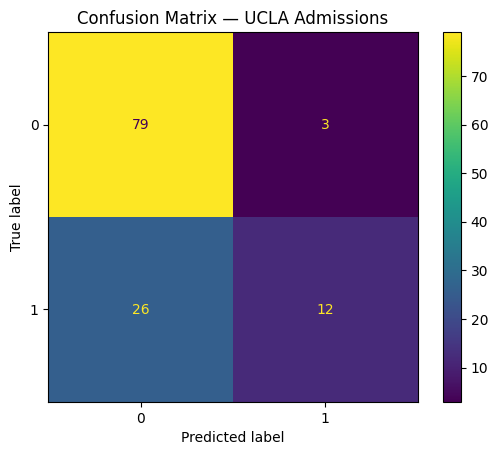

In [4]:

cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(values_format='d')
plt.title("Confusion Matrix — UCLA Admissions")
plt.show()

## Accuracy, Precision, and Recall

In [5]:

prec = metrics.precision_score(y_test, y_pred, zero_division=0)
rec  = metrics.recall_score(y_test, y_pred)
f1   = metrics.f1_score(y_test, y_pred)

print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 score:  {f1:.3f}")

Precision: 0.800
Recall:    0.316
F1 score:  0.453


## ROC curve

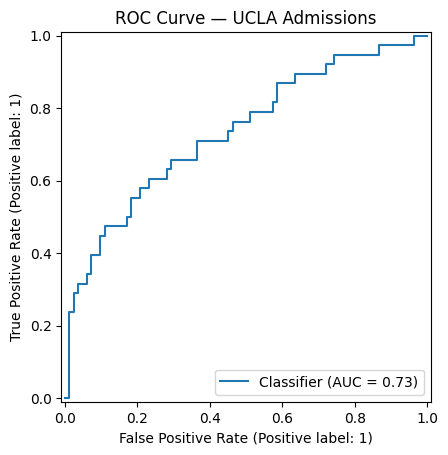

In [6]:

metrics.RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve — UCLA Admissions")
plt.show()

## ROC AUC (Area under the Curve)

In [7]:
auc  = metrics.roc_auc_score(y_test, y_prob)
print(f"AUC:       {auc:.3f}")

AUC:       0.735
